<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_09_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9 (Week 2 — Lab 4): Model Evaluation & Metrics

Welcome to Lab 9! So far you've measured your classifiers using accuracy alone. In this lab you'll go deeper: confusion matrices, precision, recall, F1-score, ROC curves, and cross-validation.

**For detailed theory on each metric, see the Lab 9 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab uses the Titanic dataset. It loads directly from a URL — no download or upload needed.

In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
print(df["Survived"].value_counts())   # notice the class imbalance
df.head()

(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quick Preparation

A short cleanup before modeling: fill missing `Age` with the median, encode `Sex` as 0/1, and select a handful of relevant features. (Full data cleaning was covered in Lab 3 — here we keep it minimal since the focus is evaluation.)

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = df[features]
y = df["Survived"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained. Test accuracy:", model.score(X_test, y_test))

Model trained. Test accuracy: 0.8100558659217877


## Example 1: Confusion Matrix

[[92 13]
 [21 53]]


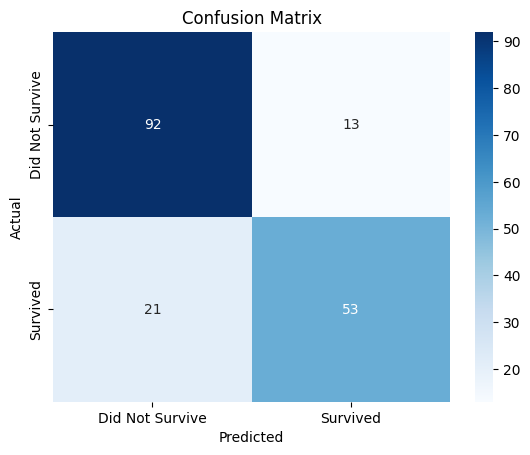

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Did Not Survive", "Survived"], yticklabels=["Did Not Survive", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Example 2: Precision, Recall & F1-Score

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred))

Precision: 0.80
Recall: 0.72
F1-Score: 0.76

Full classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Example 3: ROC Curve & AUC

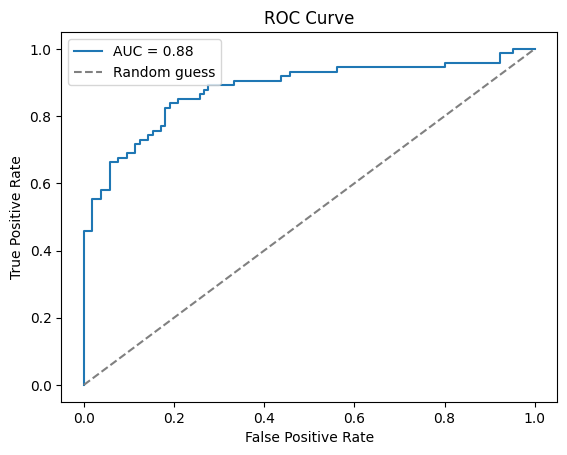

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Example 4: Cross-Validation

In [7]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("Accuracy for each of the 5 folds:", cv_scores)
print("Average accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Accuracy for each of the 5 folds: [0.7877095  0.7752809  0.78089888 0.75842697 0.82022472]
Average accuracy: 0.7845081915761722
Standard deviation: 0.020319050642552603


## Practice Exercise 1: Evaluate a Different Model

**Exercise:** Train a Decision Tree classifier (`max_depth=4`) on the same `X_train`, `y_train`. Compute and print its precision, recall, and F1-score on the test set. How do these compare to Logistic Regression?

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

### YOUR CODE HERE ###
# Initialize and train the model
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Compute metrics
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
### END ###

print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-Score:", f1_tree)

Precision: 0.796875
Recall: 0.6891891891891891
F1-Score: 0.7391304347826086


## Practice Exercise 2: Changing the Decision Threshold

By default, a probability >= 0.5 is classified as the positive class. Lowering this threshold increases recall (catches more positives) but usually decreases precision.

**Exercise:** Using `y_probs` from Example 3, create new predictions using a threshold of 0.3 instead of 0.5, then compute the new precision and recall. Compare them to the original (threshold 0.5) values from Example 2.

In [11]:
y_pred_threshold_03 = (y_probs >= 0.3).astype(int)
precision_03 = precision_score(y_test, y_pred_threshold_03)
recall_03 = recall_score(y_test, y_pred_threshold_03)

### YOUR CODE HERE ###
# No further code needed as logic is implemented above.
### END ###

print("Precision (threshold=0.3):", precision_03)
print("Recall (threshold=0.3):", recall_03)

Precision (threshold=0.3): 0.7032967032967034
Recall (threshold=0.3): 0.8648648648648649


## Practice Exercise 3: Cross-Validation with a Different Model

**Exercise:** Run 5-fold cross-validation on a Decision Tree (`max_depth=4`) instead of Logistic Regression, using the same `X` and `y`. Print the average accuracy and compare it to the Logistic Regression cross-validation score from Example 4.

In [12]:
### YOUR CODE HERE ###
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Initialize the model
tree_cv_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Perform 5-fold cross-validation
cv_scores_tree = cross_val_score(tree_cv_model, X, y, cv=5, scoring='accuracy')

print("Decision Tree CV Scores:", cv_scores_tree)
print("Average Accuracy:", cv_scores_tree.mean())
print("Standard Deviation:", cv_scores_tree.std())
### END ###

Decision Tree CV Scores: [0.75977654 0.8258427  0.80898876 0.78651685 0.84269663]
Average Accuracy: 0.8047642960266147
Standard Deviation: 0.029181756869796648


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Full Evaluation**: For your Logistic Regression model, print the confusion matrix, precision, recall, F1-score, and AUC in one organized cell.
2. **Model Comparison**: Train Logistic Regression, KNN (k=5), and a Decision Tree (max_depth=4) on this dataset. Create a summary table comparing their precision, recall, and F1-score.
3. **Threshold Analysis**: Try 3 different thresholds (e.g., 0.3, 0.5, 0.7) on your Logistic Regression model's probabilities. For each, print precision and recall, and explain the trade-off you observe.
4. **Cross-Validation Comparison**: Run 5-fold cross-validation for all three models from Task 2, and report which model has the most consistent (lowest standard deviation) performance across folds.
5. **Reflection**: In a markdown cell, write 3-4 sentences on which metric (precision, recall, or F1) you think matters most for predicting Titanic survival, and why.

--- Logistic Regression Evaluation ---
Precision: 0.8030
Recall:    0.7162
F1-Score:  0.7571
AUC-ROC:   0.8803


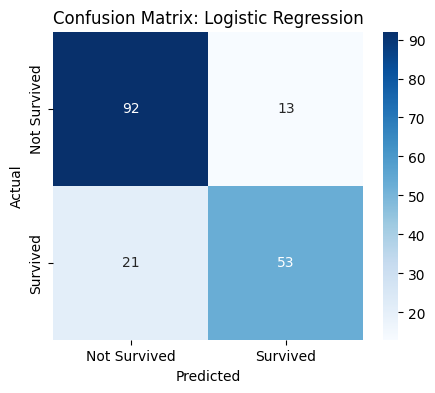

In [13]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate all metrics for the Logistic Regression model
cm = confusion_matrix(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_probs)

print("--- Logistic Regression Evaluation ---")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1_val:.4f}")
print(f"AUC-ROC:   {auc_val:.4f}")

# Display Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

# Create summary table
comparison_df = pd.DataFrame(results)
print("--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

--- Model Comparison Table ---
                      Model  Precision   Recall  F1-Score
        Logistic Regression   0.803030 0.716216  0.757143
                  KNN (k=5)   0.650000 0.527027  0.582090
Decision Tree (max_depth=4)   0.796875 0.689189  0.739130


In [15]:
thresholds = [0.3, 0.5, 0.7]

print("--- Threshold Analysis (Logistic Regression) ---")
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f"Threshold: {t} | Precision: {p:.4f} | Recall: {r:.4f}")

print("\nTrade-off Observation:")
print("As the threshold increases, Precision generally rises because the model only predicts 'Survived' when it is more confident, reducing false positives.")
print("However, Recall drops because the stricter criteria cause the model to miss more actual survivors (increasing false negatives).")

--- Threshold Analysis (Logistic Regression) ---
Threshold: 0.3 | Precision: 0.7033 | Recall: 0.8649
Threshold: 0.5 | Precision: 0.8030 | Recall: 0.7162
Threshold: 0.7 | Precision: 0.9512 | Recall: 0.5270

Trade-off Observation:
As the threshold increases, Precision generally rises because the model only predicts 'Survived' when it is more confident, reducing false positives.
However, Recall drops because the stricter criteria cause the model to miss more actual survivors (increasing false negatives).


In [16]:
from sklearn.model_selection import cross_val_score

# We will reuse the 'models' dictionary created in Task 2
cv_comparison = []

print("--- Cross-Validation Comparison (5-fold) ---")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    cv_comparison.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std Deviation": scores.std()
    })

cv_df = pd.DataFrame(cv_comparison)
print(cv_df.to_string(index=False))

most_consistent = cv_df.loc[cv_df['Std Deviation'].idxmin()]['Model']
print(f"\nThe most consistent model (lowest standard deviation) is: {most_consistent}")

--- Cross-Validation Comparison (5-fold) ---
                      Model  Mean Accuracy  Std Deviation
        Logistic Regression       0.784508       0.020319
                  KNN (k=5)       0.691426       0.034080
Decision Tree (max_depth=4)       0.804764       0.029182

The most consistent model (lowest standard deviation) is: Logistic Regression


### Task 5: Reflection

**Which metric (precision, recall, or F1) do you think matters most for predicting Titanic survival, and why?**

#Task 5 Reflection

For predicting Titanic survival, recall matters most. A false negative here means predicting someone didn't survive when they actually did which corresponds to the model failing to identify the patterns (like being female, young, or in first class) that actually saved lives, the exact insight this kind of analysis is meant to surface. Precision matters too, but missing true survivors (low recall) would hide the very factors we're trying to learn about. That said, because the classes are imbalanced, F1-score is often the more honest single number to report, since it prevents the model from looking good just by leaning on the majority class (non-survivors).

>